In [22]:
from feat import Detector
import os
import pandas as pd
import cv2
import numpy as np
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import pickle


c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
data_pth = "../data/facial-emotion-preprocessed"


In [24]:
detector = Detector(
    face_model="retinaface",
    landmark_model="mobilefacenet",
    au_model="xgb",
    emotion_model="resmasknet"
)

c:\Users\baklu\Documents\NTNU\IT3212\.venv\Lib\site-packages\feat\face_detectors\Retinaface\Retinaface_test.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_d

In [25]:
AU_COLS = [
    "AU01", "AU02", "AU04", "AU05", "AU06", "AU07",
    "AU09", "AU10", "AU12", "AU14", "AU15", "AU17",
    "AU20", "AU23", "AU24", "AU25", "AU26"
]

X = []
y = []
X_pths = []

for root, _, files in tqdm(os.walk(data_pth)):
    for file in files:
        filepth = os.path.join(root, file)

        emotion = os.path.splitext(file)[0]

        result = detector.detect_image(filepth)

        if result.aus is None or len(result.aus) == 0:
            print(f"[Warning] No face detected in: {fpath}")
            continue

        aus = result.aus.iloc[0][AU_COLS].values

        X.append(aus)
        y.append(emotion)
        X_pths.append(filepth)

X = np.array(X)
y = np.array(y)
X_pths = np.array(X_pths)



100%|██████████| 1/1 [00:01<00:00,  1.12s/it]




100%|██████████| 1/1 [00:01<00:00,  1.02s/it]




100%|██████████| 1/1 [00:00<00:00,  1.07it/s]





100%|██████████| 1/1 [00:01<00:00,  1.04s/it]

100%|██████████| 1/1 [00:01<00:00,  1.04s/it]


100%|██████████| 1/1 [00:01<00:00,  1.00s/it]




100%|██████████| 1/1 [00:01<00:00,  1.06s/it]




100%|██████████| 1/1 [00:01<00:00,  1.16s/it]





100%|██████████| 1/1 [00:01<00:00,  1.04s/it]


100%|██████████| 1/1 [00:01<00:00,  1.04s/it]


100%|██████████| 1/1 [00:01<00:00,  1.01s/it]

100%|██████████| 1/1 [00:01<00:00,  1.01s/it]


100%|██████████| 1/1 [00:00<00:00,  1.01it/s]




100%|██████████| 1/1 [00:00<00:00,  1.07it/s]




100%|██████████| 1/1 [00:01<00:00,  1.06s/it]





100%|██████████| 1/1 [00:01<00:00,  1.01s/it]

100%|██████████| 1/1 [00:01<00:00,  1.01s/it]


100%|██████████| 1/1 [00:00<00:00,  1.00it/s]





100%|██████████| 1/1 [00:01<00:00,  1.00s/it]

100%|██████████| 1/1 [00:01<00:00,  1.00s/it]


100%|██████████| 1

In [26]:
with open("../data/au_features.pkl", "wb") as f:
    pickle.dump((X, y, X_pths), f)


In [ ]:
with open("../data/au_features.pkl", "rb") as f:
    X, y, X_pths = pickle.load(f)


['../data/facial-emotion-preprocessed\\0\\Anger.png'
 '../data/facial-emotion-preprocessed\\0\\Contempt.png'
 '../data/facial-emotion-preprocessed\\0\\Disgust.png'
 '../data/facial-emotion-preprocessed\\0\\Fear.png'
 '../data/facial-emotion-preprocessed\\0\\Happy.png'
 '../data/facial-emotion-preprocessed\\0\\Neutral.png'
 '../data/facial-emotion-preprocessed\\0\\Sad.png'
 '../data/facial-emotion-preprocessed\\0\\Surprised.png'
 '../data/facial-emotion-preprocessed\\1\\Anger.png'
 '../data/facial-emotion-preprocessed\\1\\Contempt.png'
 '../data/facial-emotion-preprocessed\\1\\Disgust.png'
 '../data/facial-emotion-preprocessed\\1\\Fear.png'
 '../data/facial-emotion-preprocessed\\1\\Happy.png'
 '../data/facial-emotion-preprocessed\\1\\Neutral.png'
 '../data/facial-emotion-preprocessed\\1\\Sad.png'
 '../data/facial-emotion-preprocessed\\1\\Surprised.png'
 '../data/facial-emotion-preprocessed\\10\\Anger.png'
 '../data/facial-emotion-preprocessed\\10\\Contempt.png'
 '../data/facial-emotion-

In [27]:
for pth, label in zip(X_pths, y):
    print(pth, label)

../data/facial-emotion-preprocessed\0\Anger.png Anger
../data/facial-emotion-preprocessed\0\Contempt.png Contempt
../data/facial-emotion-preprocessed\0\Disgust.png Disgust
../data/facial-emotion-preprocessed\0\Fear.png Fear
../data/facial-emotion-preprocessed\0\Happy.png Happy
../data/facial-emotion-preprocessed\0\Neutral.png Neutral
../data/facial-emotion-preprocessed\0\Sad.png Sad
../data/facial-emotion-preprocessed\0\Surprised.png Surprised
../data/facial-emotion-preprocessed\1\Anger.png Anger
../data/facial-emotion-preprocessed\1\Contempt.png Contempt
../data/facial-emotion-preprocessed\1\Disgust.png Disgust
../data/facial-emotion-preprocessed\1\Fear.png Fear
../data/facial-emotion-preprocessed\1\Happy.png Happy
../data/facial-emotion-preprocessed\1\Neutral.png Neutral
../data/facial-emotion-preprocessed\1\Sad.png Sad
../data/facial-emotion-preprocessed\1\Surprised.png Surprised
../data/facial-emotion-preprocessed\10\Anger.png Anger
../data/facial-emotion-preprocessed\10\Contempt.p

In [17]:
X_neutrals = X[y == "Neutral"]
X_deviation = X.copy()
print(X_pths)
for i in range(X.shape[0]):
    j = str(X_pths[i]).split("/")[-2]
    print(j)
    X_deviation[i] -= X_neutrals[j]
        

['../data/facial-emotion-preprocessed\\0\\Anger.png'
 '../data/facial-emotion-preprocessed\\0\\Contempt.png'
 '../data/facial-emotion-preprocessed\\0\\Disgust.png'
 '../data/facial-emotion-preprocessed\\0\\Fear.png'
 '../data/facial-emotion-preprocessed\\0\\Happy.png'
 '../data/facial-emotion-preprocessed\\0\\Neutral.png'
 '../data/facial-emotion-preprocessed\\0\\Sad.png'
 '../data/facial-emotion-preprocessed\\0\\Surprised.png'
 '../data/facial-emotion-preprocessed\\1\\Anger.png'
 '../data/facial-emotion-preprocessed\\1\\Contempt.png'
 '../data/facial-emotion-preprocessed\\1\\Disgust.png'
 '../data/facial-emotion-preprocessed\\1\\Fear.png'
 '../data/facial-emotion-preprocessed\\1\\Happy.png'
 '../data/facial-emotion-preprocessed\\1\\Neutral.png'
 '../data/facial-emotion-preprocessed\\1\\Sad.png'
 '../data/facial-emotion-preprocessed\\1\\Surprised.png'
 '../data/facial-emotion-preprocessed\\10\\Anger.png'
 '../data/facial-emotion-preprocessed\\10\\Contempt.png'
 '../data/facial-emotion-

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [15]:
# Standardize AU features before clustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import confusion_matrix

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"X shape: {X.shape}")
print(f"Unique emotions (y): {np.unique(y)}")

X shape: (152, 17)
Unique emotions (y): ['Anger' 'Contempt' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad' 'Surprised']


Explained variance (2D): 0.48819143
Explained variance (3D): 0.5686367


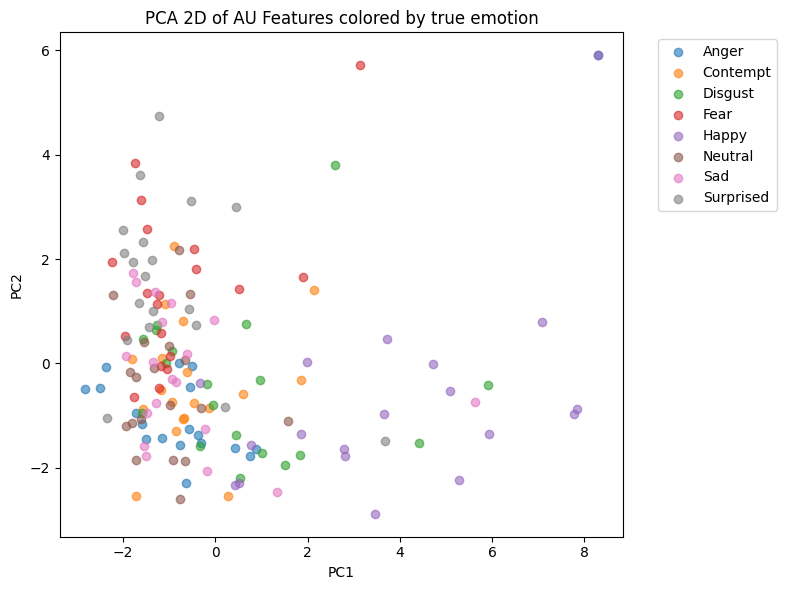

In [16]:
# PCA to 2D/3D for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print("Explained variance (2D):", pca_2d.explained_variance_ratio_.sum())
print("Explained variance (3D):", pca_3d.explained_variance_ratio_.sum())

# 2D scatter colored by true emotion
plt.figure(figsize=(8, 6))
for label in np.unique(y):
    mask = y == label
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], label=label, alpha=0.6)
plt.title("PCA 2D of AU Features colored by true emotion")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Number of unique emotions (clusters): 8
KMeans silhouette score: 0.123
KMeans adjusted rand index vs true emotions: 0.080


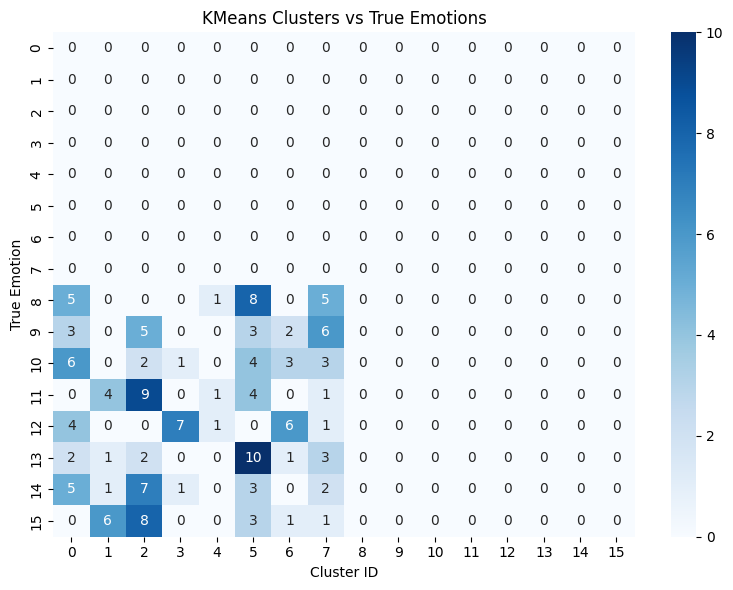

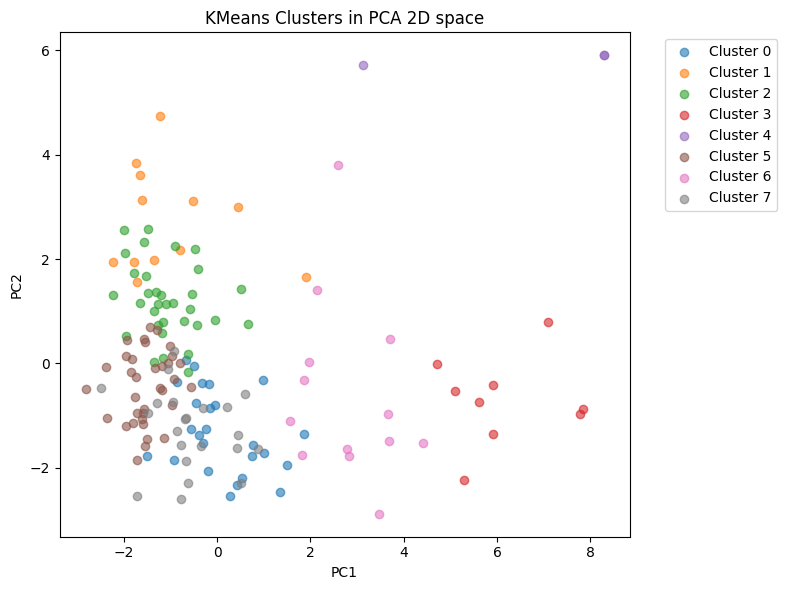

In [17]:
# KMeans clustering with k = number of emotions
n_classes = len(np.unique(y))
print(f"Number of unique emotions (clusters): {n_classes}")

kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
cluster_labels_km = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, cluster_labels_km)
ari_km = adjusted_rand_score(y, cluster_labels_km)
print(f"KMeans silhouette score: {sil_km:.3f}")
print(f"KMeans adjusted rand index vs true emotions: {ari_km:.3f}")

# Confusion matrix between true labels and clusters
y_str = y.astype(str)
cluster_labels_km_str = cluster_labels_km.astype(str)
cm_km = confusion_matrix(y_str, cluster_labels_km_str)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_km, annot=True, fmt='d', cmap='Blues')
plt.title('KMeans Clusters vs True Emotions')
plt.xlabel('Cluster ID')
plt.ylabel('True Emotion')
plt.tight_layout()
plt.show()

# Visualize clusters in PCA 2D
plt.figure(figsize=(8, 6))
for cl in np.unique(cluster_labels_km):
    mask = cluster_labels_km == cl
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], label=f"Cluster {cl}", alpha=0.6)
plt.title("KMeans Clusters in PCA 2D space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [14]:
# DBSCAN clustering (density-based)

# Try a few eps values and choose one with reasonable number of clusters
for eps in [0.3, 0.5, 0.7, 1.0]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    cluster_labels_db = dbscan.fit_predict(X_scaled)
    n_clusters_db = len(set(cluster_labels_db)) - (1 if -1 in cluster_labels_db else 0)
    n_noise = np.sum(cluster_labels_db == -1)
    print(f"\nDBSCAN eps={eps}: {n_clusters_db} clusters, {n_noise} noise points")
    if n_clusters_db > 1:
        mask_valid = cluster_labels_db != -1
        sil = silhouette_score(X_scaled[mask_valid], cluster_labels_db[mask_valid])
        ari = adjusted_rand_score(y[mask_valid], cluster_labels_db[mask_valid])
        print(f"  Silhouette (no noise): {sil:.3f}")
        print(f"  Adjusted Rand vs emotions (no noise): {ari:.3f}")

# Choose a reasonable eps manually after inspecting above output, e.g., eps = 0.5
eps_chosen = 0.5
dbscan = DBSCAN(eps=eps_chosen, min_samples=5)
cluster_labels_db = dbscan.fit_predict(X_scaled)

print(f"\nFinal DBSCAN with eps={eps_chosen}")
print("Unique labels:", set(cluster_labels_db))

# Confusion matrix for non-noise points (only if some exist)
mask_nn = cluster_labels_db != -1
if np.any(mask_nn):
    y_nn_str = y[mask_nn].astype(str)
    cluster_nn_str = cluster_labels_db[mask_nn].astype(str)
    # fixed label orders: 8 true emotions (rows) and used cluster IDs (cols)
    labels_true = sorted(list(set(y_nn_str)))
    labels_clusters = sorted(list(set(cluster_nn_str)))
    cm_db = confusion_matrix(y_nn_str, cluster_nn_str, labels=labels_clusters)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_db, annot=True, fmt='d', cmap='Purples',
                xticklabels=labels_clusters, yticklabels=labels_true)
    plt.title(f'DBSCAN (eps={eps_chosen}) Clusters vs True Emotions (no noise)')
    plt.xlabel('Cluster ID')
    plt.ylabel('True Emotion')
    plt.tight_layout()
    plt.show()
else:
    print("No non-noise points for chosen eps; skipping confusion matrix.")

# Visualize DBSCAN clusters in PCA 2D
plt.figure(figsize=(8, 6))
unique_labels = set(cluster_labels_db)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

for label_db, color in zip(unique_labels, colors):
    mask = cluster_labels_db == label_db
    if label_db == -1:
        plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c=[color], label='Noise', alpha=0.4, marker='x')
    else:
        plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c=[color], label=f'Cluster {label_db}', alpha=0.6)

plt.title(f'DBSCAN (eps={eps_chosen}) Clusters in PCA 2D space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


DBSCAN eps=0.3: 0 clusters, 152 noise points

DBSCAN eps=0.5: 0 clusters, 152 noise points

DBSCAN eps=0.7: 0 clusters, 152 noise points

DBSCAN eps=1.0: 0 clusters, 152 noise points

Final DBSCAN with eps=0.5
Unique labels: {-1}


ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 800x600 with 0 Axes>